# Лабораторная работа: Генеративные модели классификации (LDA и Naive Bayes)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal
from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)

## Часть 1. Исследование многомерного нормального распределения

### 1.1 Генерация данных с заданной ковариацией

## Часть 1. Исследование многомерного нормального распределения (10 баллов)

### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

Выборочная матрица ковариации:
[[ 0.23312293 -0.23625764]
 [-0.23625764  0.46568054]]

Теоретическая матрица ковариации:
[[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


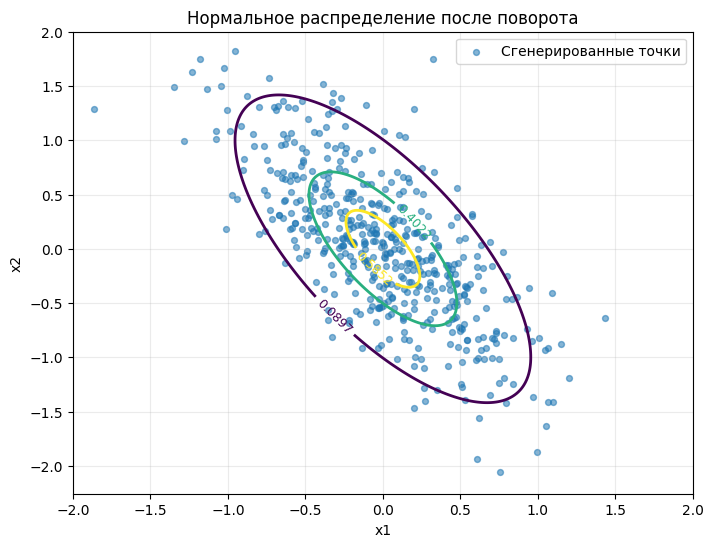

In [ ]:
# параметры генерации
M = 500
sigma1 = 0.3
sigma2 = 0.8
alpha = np.deg2rad(30)

# генерирую два независимых вектора
x1 = np.random.normal(0, sigma1, M)
x2 = np.random.normal(0, sigma2, M)
X_initial = np.column_stack([x1, x2])

# матрица поворота
R = np.array([
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha),  np.cos(alpha)]
])

# поворот точек
X = X_initial @ R.T # т.к. точки записаны строкой

# выборочная и теоретическая ковариации
C_sample = np.cov(X.T) # выборочная ковариационная матрица по полученным точкам
C_theor = R @ np.diag([sigma1**2, sigma2**2]) @ R.T # теоретическая ковариационная матрица по формуле

print('Выборочная матрица ковариации:')
print(C_sample)
print()
print('Теоретическая матрица ковариации:')
print(C_theor)

# сетка для эллипсов
xx, yy = np.meshgrid(
    np.linspace(-2, 2, 300),
    np.linspace(-2, 2, 300)
)
grid = np.column_stack([xx.ravel(), yy.ravel()]) # соединяю их в пары координат
rv_theor = multivariate_normal(mean=[0, 0], cov=C_theor) # создаю теоретическое распределение
Z = rv_theor.pdf(grid).reshape(xx.shape) # вычисляю,насколько высокая плонтость норм. распределения в (х,у)

# плотности, соответствующие расстояниям 0.5, 1 и 2 стандартных отклонения
peak = rv_theor.pdf([0, 0])
radii = np.array([0.5, 1.0, 2.0])
levels = peak * np.exp(-0.5 * radii**2)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=18, alpha=0.55, label='Сгенерированные точки')
cs = plt.contour(xx, yy, Z, levels=np.sort(levels), linewidths=2) # рисую эллипсы одинаковой плотности
plt.clabel(cs, inline=True, fontsize=9)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Нормальное распределение после поворота')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Автопроверка
assert X.shape == (M, 2), 'Неверная размерность данных'
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, 'Корреляция слишком мала (проверьте поворот)'
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), 'Среднее должно быть около 0'

Поворот независимых признаков создал ненулевую ковариацию между координатами. Выборочная матрица ковариации близка к теоретической.

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

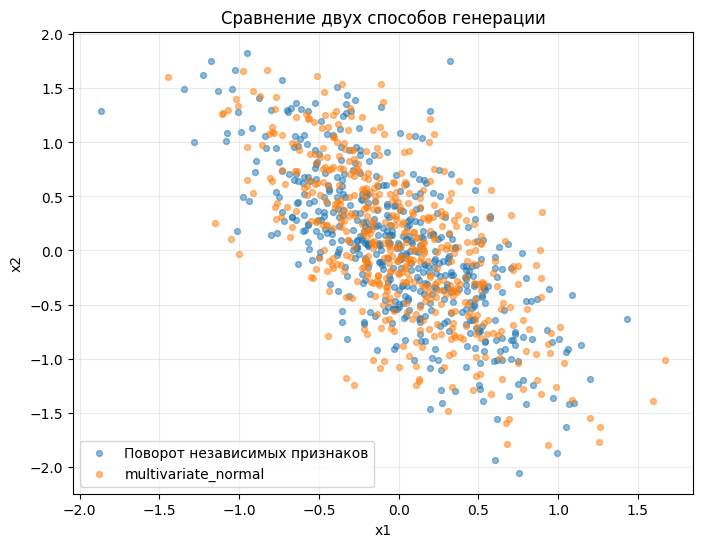

In [ ]:
# генерация встроенной функцией с той же ковариацией
X_2 = np.random.multivariate_normal(mean=[0, 0], cov=C_theor, size=M)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=18, alpha=0.5, label='Поворот независимых признаков')
plt.scatter(X_2[:, 0], X_2[:, 1], s=18, alpha=0.5, label='multivariate_normal')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Сравнение двух способов генерации')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

**Ответ:** облака визуально совпадают, потому что оба способа задают одно и то же двумерное нормальное распределение с одинаковыми средним и ковариацией. Отдельные точки не совпадают из-за случайности выборки.

`np.random.multivariate_normal` предпочтительнее, когда ковариационная матрица уже известна: функция сразу генерирует данные с нужной зависимостью признаков и уменьшает количество ручных преобразований.

**Вывод:** оба способа дают выборки из одного распределения, но встроенная функция компактнее и удобнее.

## Часть 2. Визуализация плотности вероятности

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

Максимальная разница: 2.7755575615628914e-16


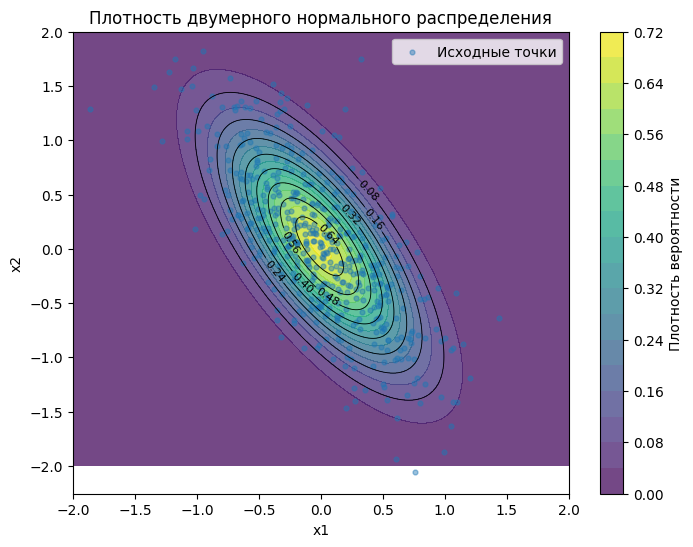

In [ ]:
# выборочные оценки среднего каждого признака и ковариации
mu_hat = np.mean(X, axis=0)
C_hat = np.cov(X.T)

# сетка точек
x_grid = np.linspace(-2, 2, 250)
y_grid = np.linspace(-2, 2, 250)
xx2, yy2 = np.meshgrid(x_grid, y_grid) #создаю сетку из всех комбинаций х м у
grid_points = np.column_stack([xx2.ravel(), yy2.ravel()]) # делаю из сетки пары координат

# 1. PDF через scipy
m = multivariate_normal(mean=mu_hat, cov=C_hat)
pdf_scipy = m.pdf(grid_points)

# 2. PDF вручную
n_features = X.shape[1] # кол-во признаков
det_C = np.linalg.det(C_hat) # определитель ковар. м-цы
inv_C = np.linalg.inv(C_hat) # обратная м-ца к ковариационной
diff = grid_points - mu_hat
quadratic = np.sum((diff @ inv_C) * diff, axis=1) # для каждый т. вычисляем квадратичную часть ф-лы
normalizer = 1 / np.sqrt((2 * np.pi)**n_features * det_C) # коэфф. перед exp
pdf_manual = normalizer * np.exp(-0.5 * quadratic)

max_diff = np.max(np.abs(pdf_manual - pdf_scipy)) # разница между результатом 1 и 2 способа
print('Максимальная разница:', max_diff)

assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), 'Ручное вычисление отличается от scipy'

# визуализация плотности
Z_pdf = pdf_scipy.reshape(xx2.shape)
plt.figure(figsize=(8, 6))
cf = plt.contourf(xx2, yy2, Z_pdf, levels=20, alpha=0.75)
cs = plt.contour(xx2, yy2, Z_pdf, levels=10, colors='black', linewidths=0.6)
plt.clabel(cs, inline=True, fontsize=8, fmt='%.2f')
plt.scatter(X[:, 0], X[:, 1], s=12, alpha=0.45, label='Исходные точки')
plt.colorbar(cf, label='Плотность вероятности')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Плотность двумерного нормального распределения')
plt.legend()
plt.show()

**Краткий вывод.** Ручная формула и `scipy.stats.multivariate_normal` дают практически одинаковые значения плотности. Максимальная разница обусловлена только численной погрешностью.

## Часть 3. Бинарная классификация через байесовский подход

**Цель:** визуализировать разделяющую поверхность для двух классов.

### 3.1 Генерация датасета
Создайте два класса (по 300 точек каждый):
- **Класс 0:** $ \mu_0 = (-0.5, 0.5) $, $ C_0 = \begin{bmatrix} 0.2 & 0.1 \\ 0.1 & 0.3 \end{bmatrix} $
- **Класс 1:** $ \mu_1 = (0.5, -0.5) $, $ C_1 = \begin{bmatrix} 0.3 & -0.1 \\ -0.1 & 0.2 \end{bmatrix} $

### 3.2 Визуализация апостериорной вероятности
Для каждой точки сетки вычислите:
$
\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)
$
где $ p(y) $ оценивается как доля объектов класса в выборке.

**Визуализация:**
- Scatter plot точек классов (разными цветами).
- Заливка фона: положительные значения $ \Delta $ — одним цветом (например, синим), отрицательные — другим (красным).
- Линия, где $ \Delta(x) = 0 $ (разделяющая поверхность) — через `plt.contour(..., levels=[0])`.

**Вопрос (ответить текстом):** является ли разделяющая поверхность линейной? Почему?


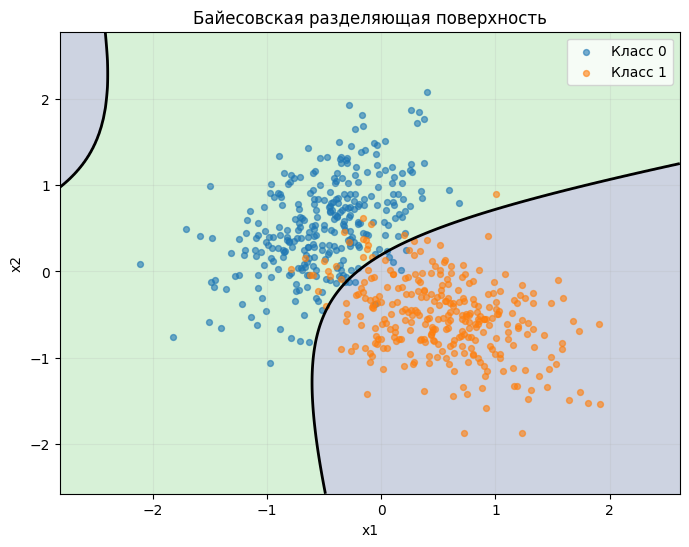

In [ ]:
# параметры классов
mu0 = np.array([-0.5, 0.5])
mu1 = np.array([0.5, -0.5])
C0 = np.array([[0.2, 0.1], [0.1, 0.3]])
C1 = np.array([[0.3, -0.1], [-0.1, 0.2]])

# генерация данных
X0 = np.random.multivariate_normal(mu0, C0, 300)
X1 = np.random.multivariate_normal(mu1, C1, 300)
X_bayes = np.vstack([X0, X1])
y_bayes = np.hstack([np.zeros(300, dtype=int), np.ones(300, dtype=int)])

# априорные вероятности
p0 = np.mean(y_bayes == 0)
p1 = np.mean(y_bayes == 1)

# определяю границы графика по имеющмся точкам
x_min, x_max = X_bayes[:, 0].min() - 0.7, X_bayes[:, 0].max() + 0.7
y_min, y_max = X_bayes[:, 1].min() - 0.7, X_bayes[:, 1].max() + 0.7
xx3, yy3 = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid3 = np.column_stack([xx3.ravel(), yy3.ravel()]) # из сетки делаю пары координат

# delta(x) = p(x|0)p(0) - p(x|1)p(1), создаю нормальные распределения для 2х классов
dist0 = multivariate_normal(mean=mu0, cov=C0)
dist1 = multivariate_normal(mean=mu1, cov=C1)
delta = (dist0.pdf(grid3) * p0 - dist1.pdf(grid3) * p1).reshape(xx3.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx3, yy3, delta, levels=[delta.min(), 0, delta.max()], alpha=0.25)
plt.contour(xx3, yy3, delta, levels=[0], colors='black', linewidths=2)
plt.scatter(X0[:, 0], X0[:, 1], s=18, alpha=0.6, label='Класс 0')
plt.scatter(X1[:, 0], X1[:, 1], s=18, alpha=0.6, label='Класс 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Байесовская разделяющая поверхность')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

**Ответ:** разделяющая поверхность не является линейной. У классов разные ковариационные матрицы, поэтому квадратичные слагаемые не сокращаются, в результате чего граница имеет квадратичную форму.

**Краткий вывод:** различие ковариаций классов приводит к нелинейной байесовской границе.

## Часть 4. Линейный дискриминантный анализ (LDA)

### 4.1 Теоретический вывод
**Задание:** выведите явное выражение для разделяющей поверхности в случае, когда $ C_0 = C_1 = C $. Покажите, что она линейна. Напишите формулу для весов $ w $ и порога $ b $ в уравнении $ w^T x + b = 0 $.

**Ответ:** при одинаковой ковариационной матрице $C$ для классов $0$ и $1$ вводится функция:

$$
\delta_k(x)=
-\frac{1}{2}(x-\mu_k)^T C^{-1}(x-\mu_k)
+\log p(y=k).
$$

Граница между классами задаётся условием:

$$
\delta_1(x)-\delta_0(x)=0.
$$

После раскрытия скобок квадратичные по $x$ члены

$$
x^T C^{-1}x
$$

сокращаются, так как ковариационная матрица $C$ одинакова для обоих классов. Получаем:

$$
(\mu_1-\mu_0)^T C^{-1}x
-\frac{1}{2}\mu_1^T C^{-1}\mu_1
+\frac{1}{2}\mu_0^T C^{-1}\mu_0
+\log\frac{p(y=1)}{p(y=0)}
=0.
$$

Следовательно, разделяющая граница является линейной и имеет вид

$$
w^T x+b=0,
$$

где

$$
w=C^{-1}(\mu_1-\mu_0),
$$

а

$$
b=
-\frac{1}{2}\mu_1^T C^{-1}\mu_1
+\frac{1}{2}\mu_0^T C^{-1}\mu_0
+\log\frac{p(y=1)}{p(y=0)}.
$$

Таким образом, при одинаковых ковариационных матрицах классов байесовская классификация приводит к линейной разделяющей границе, что лежит в основе линейного дискриминантного анализа (LDA).

### 4.2 Реализация класса LDA
Реализуйте класс `MyLDA`, следуя шаблону.

**Указания:**
- Для устойчивости добавьте небольшой регуляризатор к ковариационной матрице: `cov_reg = cov + 1e-6 * np.eye(n_features)`.
- Формула для весов для бинарного случая:
  $
  w = C^{-1} (\mu_1 - \mu_0)
  $

  $
  b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)}
  $

In [ ]:
class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y) # нахожу уникальные классы
        # создаю словари для средних и апр. вероятностей
        self.means_ = {}
        self.priors_ = {}

        n_samples, n_features = X.shape # число объектов и число признаков

        # средние и априорные вероятности классов
        for cls in self.classes_:
            X_cls = X[y == cls]
            self.means_[cls] = X_cls.mean(axis=0) # ср. значение каждого признака внутри класса
            self.priors_[cls] = len(X_cls) / n_samples # доля объектов этого класса

        # общая внутриклассовая ковариационная матрица
        cov = np.zeros((n_features, n_features))
        for cls in self.classes_:
            X_cls = X[y == cls]
            centered = X_cls - self.means_[cls] # из каждого объекта вычитаю среднее класса
            cov += centered.T @ centered # +вклад данного класса в общую ковар. м-цу
        cov /= n_samples

        self.cov_ = cov + 1e-6 * np.eye(n_features)
        inv_cov = np.linalg.inv(self.cov_) # нахожу обратную м-цу

        # параметры бинарной разделяющей функции
        if len(self.classes_) == 2:
            c0, c1 = self.classes_
            # среднее двух классов
            mu0 = self.means_[c0]
            mu1 = self.means_[c1]
            self.coef_ = inv_cov @ (mu1 - mu0)
            # вычисляю свободный коэффицент b
            self.intercept_ = (
                -0.5 * mu1 @ inv_cov @ mu1
                + 0.5 * mu0 @ inv_cov @ mu0
                + np.log(self.priors_[c1] / self.priors_[c0])
            )

        return self

    def _scores(self, X):
        X = np.asarray(X, dtype=float)
        inv_cov = np.linalg.inv(self.cov_) # нахожу обратную ковар. м-цу
        scores = []

        for cls in self.classes_:
            mu = self.means_[cls]
            # считаю по формуле LDA
            score = (
                X @ inv_cov @ mu
                - 0.5 * mu @ inv_cov @ mu
                + np.log(self.priors_[cls])
            )
            scores.append(score)

        return np.column_stack(scores)

    def predict(self, X):
        scores = self._scores(X)
        return self.classes_[np.argmax(scores, axis=1)]

    def predict_proba(self, X):
        scores = self._scores(X)
        scores = scores - scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

### 4.3 Проверка на синтетике
- Создайте два класса с одинаковой ковариацией $ C = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix} $, но разными средними.
- Обучите ваш `MyLDA` и сравните предсказания с `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`.
- Визуализируйте разделяющую прямую и точки.

Доля совпавших предсказаний: 1.0
Accuracy MyLDA: 0.972
Accuracy sklearn LDA: 0.972


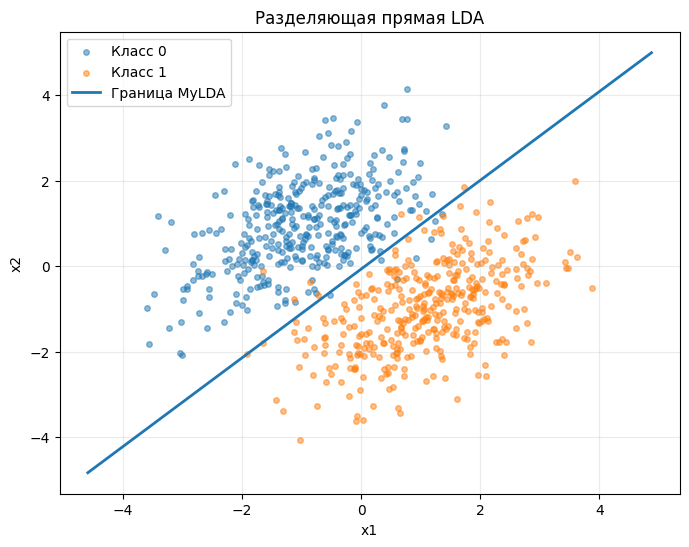

In [ ]:
# синтетические данные с общей ковариацией
C_equal = np.array([[1.0, 0.5], [0.5, 1.0]])
X0_lda = np.random.multivariate_normal([-1.0, 1.0], C_equal, 500)
X1_lda = np.random.multivariate_normal([1.0, -1.0], C_equal, 500)
X_lda = np.vstack([X0_lda, X1_lda]) # объединячю точки двух классов в один массив
y_lda = np.hstack([np.zeros(500, dtype=int), np.ones(500, dtype=int)])

# делю данные на обучающую и тестовые выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y_lda, test_size=0.25, random_state=42, stratify=y_lda
)

my_lda = MyLDA().fit(X_train, y_train)
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)

pred_my = my_lda.predict(X_test)
pred_sk = sk_lda.predict(X_test)

print('Доля совпавших предсказаний:', np.mean(pred_my == pred_sk))
print('Accuracy MyLDA:', accuracy_score(y_test, pred_my))
print('Accuracy sklearn LDA:', accuracy_score(y_test, pred_sk))

assert np.mean(pred_my == pred_sk) > 0.99, 'Предсказания заметно отличаются'

# Проверка направления векторов весов
w_my = my_lda.coef_ / np.linalg.norm(my_lda.coef_)
w_sk = sk_lda.coef_.ravel() / np.linalg.norm(sk_lda.coef_.ravel())
assert np.allclose(w_my, w_sk, atol=1e-3), 'Вектора весов имеют разные направления'

# Визуализация разделяющей прямой
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], s=16, alpha=0.5, label='Класс 0')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], s=16, alpha=0.5, label='Класс 1')

x_line = np.linspace(X_lda[:, 0].min() - 1, X_lda[:, 0].max() + 1, 300)
w = my_lda.coef_
b = my_lda.intercept_
y_line = -(w[0] * x_line + b) / w[1]
plt.plot(x_line, y_line, linewidth=2, label='Граница MyLDA')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Разделяющая прямая LDA')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

**Краткий вывод.** При общей ковариационной матрице LDA строит линейную границу. Реализация `MyLDA` дает практически те же предсказания и то же направление разделяющего вектора, что и `sklearn`.

## Часть 5. Наивный байесовский классификатор (NB)

### 5.1 Теоретическое обоснование
**Вопрос:** почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $ p(x|y) $?

**Ответ:** в наивном байесовском классификаторе предполагается условная независимость признаков при фиксированном классе. Поэтому совместная плотность раскладывается в произведение одномерных плотностей:

$$
p(x|y)=\prod_i p(x_i|y).
$$

При таком предположении ковариации между разными признаками считаются равными нулю, поэтому ковариационная матрица диагональна. Это упрощает вычисления: вместо обращения полной матрицы ковариации достаточно хранить и использовать отдельную дисперсию каждого признака. Вероятность объекта вычисляется как произведение одномерных нормальных плотностей, а на практике используется сумма их логарифмов.

### 5.2 Реализация класса NB
Реализуйте класс `MyNB`.

**Важно:** используйте **логарифмическое правдоподобие** для численной устойчивости:
$
\log p(y|x) \propto \log p(y) + \sum_i \log p(x_i|y) = \log p(y) - \frac{1}{2}\sum_i \left( \log(2\pi\sigma_{y,i}^2) + \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2} \right)
$


In [ ]:
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None
        self.vars_ = None
        self.priors_ = None
        self.epsilon_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}

        self.epsilon_ = 1e-9 * np.var(X, axis=0).max()

        for cls in self.classes_:
            X_cls = X[y == cls]
            self.means_[cls] = X_cls.mean(axis=0)
            self.vars_[cls] = X_cls.var(axis=0) + self.epsilon_
            self.priors_[cls] = len(X_cls) / len(X)

        return self

    def _joint_log_likelihood(self, X):
        X = np.asarray(X, dtype=float)
        scores = []

        for cls in self.classes_:
            mean = self.means_[cls]
            var = self.vars_[cls]
            log_likelihood = -0.5 * np.sum(
                np.log(2 * np.pi * var) + ((X - mean) ** 2) / var,
                axis=1
            )
            scores.append(np.log(self.priors_[cls]) + log_likelihood)

        return np.column_stack(scores)

    def predict(self, X):
        scores = self._joint_log_likelihood(X)
        return self.classes_[np.argmax(scores, axis=1)]

### 5.3 Сравнение с sklearn
- Сравните ваш `MyNB` с `sklearn.naive_bayes.GaussianNB` на тех же данных.
- Убедитесь, что предсказания совпадают (с точностью до численных погрешностей).

In [ ]:
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)

pred_my_nb = my_nb.predict(X_test)
pred_sk_nb = sk_nb.predict(X_test)

print('Доля совпавших предсказаний:', np.mean(pred_my_nb == pred_sk_nb))
print('Accuracy MyNB:', accuracy_score(y_test, pred_my_nb))
print('Accuracy sklearn GaussianNB:', accuracy_score(y_test, pred_sk_nb))

assert np.allclose(pred_my_nb, pred_sk_nb), 'Предсказания NB не совпадают'

Доля совпавших предсказаний: 1.0
Accuracy MyNB: 0.98
Accuracy sklearn GaussianNB: 0.98


**Краткий вывод.** `MyNB` использует те же оценки средних, дисперсий и априорных вероятностей, что и Gaussian Naive Bayes. Предсказания совпадают с `sklearn`.

## Часть 6. Экспериментальное сравнение LDA и NB

### 6.1 Генерация датасетов с разной структурой
Создайте **три** различных датасета для бинарной классификации:

1. **Датасет A (LDA-оптимальный):** классы имеют одинаковую ковариацию, но разные средние.
2. **Датасет B (NB-оптимальный):** признаки независимы внутри каждого класса, но ковариации классов разные.
3. **Датасет C (сложный):** признаки коррелированы, ковариации классов разные.

Используйте `sklearn.datasets.make_classification` с параметрами:
- `n_features=10` (для проверки многомерности)
- `n_informative=5`, `n_redundant=2`
- Для датасета C: `flip_y=0.05` (немного шума).

In [ ]:
def impose_class_covariance(X, y, covariances, target_means=None):
    """Преобразует признаки каждого класса под заданные средние и ковариации."""
    X_new = np.zeros_like(X, dtype=float)

    for cls in np.unique(y):
        X_cls = X[y == cls]
        current_mean = X_cls.mean(axis=0)
        centered = X_cls - current_mean

        # Whitening текущего класса
        current_cov = np.cov(centered, rowvar=False) + 1e-6 * np.eye(X.shape[1])
        eigvals, eigvecs = np.linalg.eigh(current_cov)
        whitening = eigvecs @ np.diag(1 / np.sqrt(eigvals)) @ eigvecs.T
        Z = centered @ whitening.T

        # Coloring под нужную ковариацию
        target_cov = covariances[cls]
        eigvals_t, eigvecs_t = np.linalg.eigh(target_cov)
        coloring = eigvecs_t @ np.diag(np.sqrt(eigvals_t)) @ eigvecs_t.T

        target_mean = current_mean if target_means is None else np.asarray(target_means[cls], dtype=float)
        X_new[y == cls] = Z @ coloring.T + target_mean

    return X_new

# Базовые данные создаются через make_classification согласно условию
X_A, y_A = make_classification(
    n_samples=1500, n_features=10, n_informative=5, n_redundant=2,
    n_classes=2, class_sep=1.8, flip_y=0.0, random_state=1
)
X_B, y_B = make_classification(
    n_samples=1500, n_features=10, n_informative=5, n_redundant=2,
    n_classes=2, class_sep=1.5, flip_y=0.0, random_state=2
)
X_C, y_C = make_classification(
    n_samples=1500, n_features=10, n_informative=5, n_redundant=2,
    n_classes=2, class_sep=1.2, flip_y=0.05, random_state=3
)

n = 10

# A: одинаковая полная ковариация для обоих классов, разные средние
base_cov_A = 0.35 * np.ones((n, n)) + 0.65 * np.eye(n)
mean_A0 = np.array([-0.8, -0.8, -0.6, -0.6, -0.4, 0, 0, 0, 0, 0])
mean_A1 = -mean_A0
X_A = impose_class_covariance(
    X_A, y_A,
    {0: base_cov_A, 1: base_cov_A},
    {0: mean_A0, 1: mean_A1}
)

# B: независимые признаки, разные диагональные ковариации
cov_B0 = np.diag([0.20, 0.25, 0.30, 0.35, 0.40, 1.50, 1.60, 1.70, 1.80, 1.90])
cov_B1 = np.diag([1.90, 1.80, 1.70, 1.60, 1.50, 0.40, 0.35, 0.30, 0.25, 0.20])
mean_B0 = np.zeros(n)
mean_B1 = np.zeros(n)
X_B = impose_class_covariance(
    X_B, y_B,
    {0: cov_B0, 1: cov_B1},
    {0: mean_B0, 1: mean_B1}
)

# C: разные коррелированные ковариации и шум в метках
A0 = np.eye(n)
A0[0, 1] = A0[1, 0] = 0.65
A0[2, 3] = A0[3, 2] = -0.45
A1 = np.eye(n)
A1[0, 1] = A1[1, 0] = -0.55
A1[4, 5] = A1[5, 4] = 0.60
mean_C0 = np.array([-0.45, -0.35, -0.25, -0.15, -0.10, 0, 0, 0, 0, 0])
mean_C1 = -mean_C0
X_C = impose_class_covariance(
    X_C, y_C,
    {0: A0, 1: A1},
    {0: mean_C0, 1: mean_C1}
)

datasets = {
    'A': (X_A, y_A),
    'B': (X_B, y_B),
    'C': (X_C, y_C)
}

for name, (Xd, yd) in datasets.items():
    print(f'Датасет {name}: X={Xd.shape}, y={yd.shape}')

Датасет A: X=(1500, 10), y=(1500,)
Датасет B: X=(1500, 10), y=(1500,)
Датасет C: X=(1500, 10), y=(1500,)


### 6.2 Сравнение моделей
Для каждого датасета:
1. Разделите на train/test (80/20).
2. Обучите `MyLDA`, `MyNB`, а также (для бенчмарка) `sklearn.linear_model.LogisticRegression`.
3. Посчитайте метрики: **Accuracy**, **Precision**, **Recall**, **F1-score** (для каждого класса отдельно и macro-усредненные).
4. Постройте confusion matrix для каждой модели.


===== Датасет A =====


,Dataset,Model,Accuracy,Precision class 0,Precision class 1,Recall class 0,Recall class 1,F1 class 0,F1 class 1,Precision macro,Recall macro,F1 macro
0,A,MyLDA,1.0000,1.0000,1.0000,1.00,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,A,MyNB,0.8433,0.8323,0.8552,0.86,0.8267,0.8459,0.8407,0.8437,0.8433,0.8433
2,A,LogisticRegression,1.0000,1.0000,1.0000,1.00,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


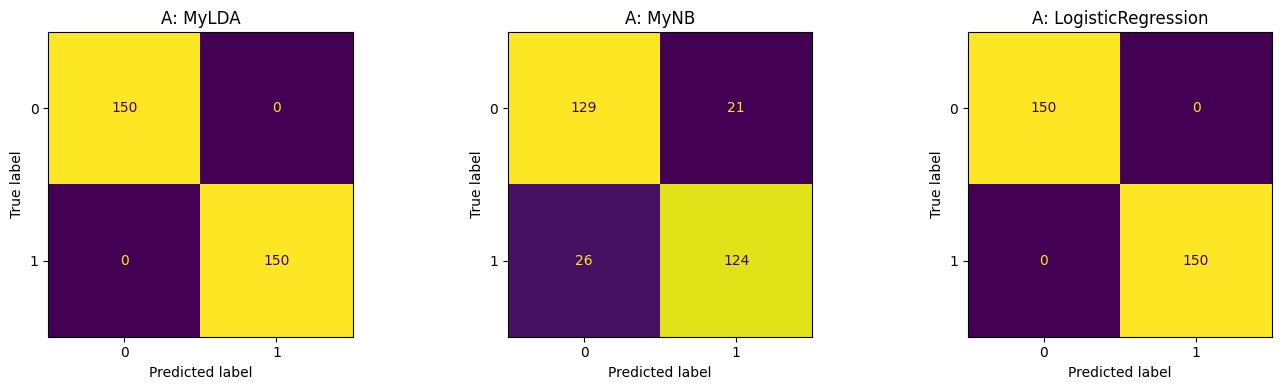

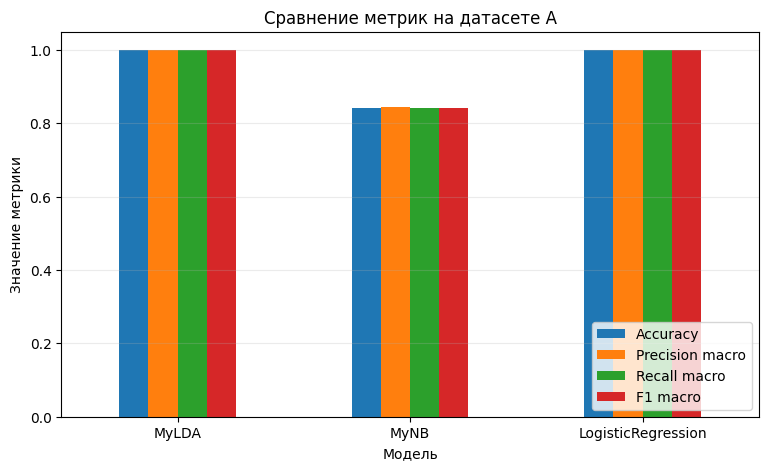


===== Датасет B =====


,Dataset,Model,Accuracy,Precision class 0,Precision class 1,Recall class 0,Recall class 1,F1 class 0,F1 class 1,Precision macro,Recall macro,F1 macro
0,B,MyLDA,0.4500,0.4444,0.4545,0.4000,0.5000,0.4211,0.4762,0.4495,0.4500,0.4486
1,B,MyNB,0.9833,0.9739,0.9932,0.9933,0.9733,0.9835,0.9832,0.9835,0.9833,0.9833
2,B,LogisticRegression,0.4433,0.4380,0.4479,0.4000,0.4867,0.4181,0.4665,0.4429,0.4433,0.4423


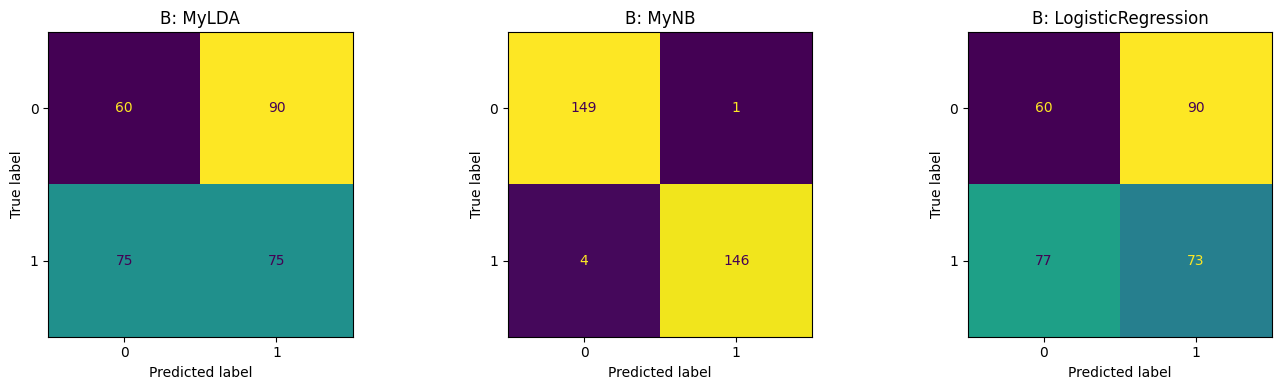

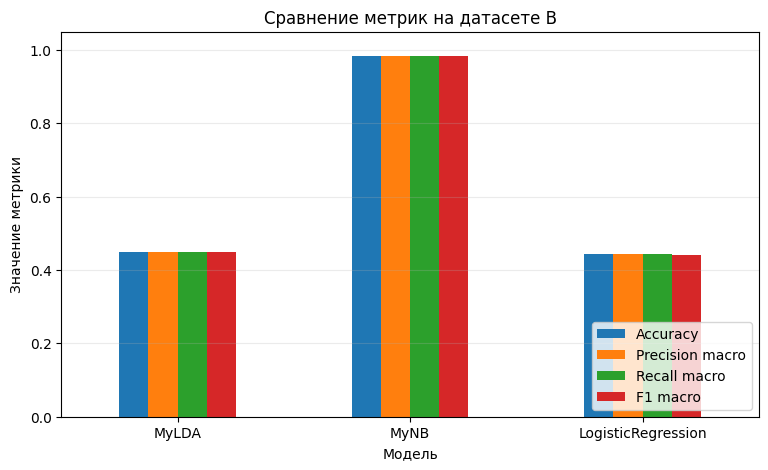


===== Датасет C =====


,Dataset,Model,Accuracy,Precision class 0,Precision class 1,Recall class 0,Recall class 1,F1 class 0,F1 class 1,Precision macro,Recall macro,F1 macro
0,C,MyLDA,0.9000,0.8580,0.9542,0.9603,0.8389,0.9062,0.8929,0.9061,0.8996,0.8996
1,C,MyNB,0.7333,0.7483,0.7197,0.7086,0.7584,0.7279,0.7386,0.7340,0.7335,0.7332
2,C,LogisticRegression,0.8867,0.8503,0.9323,0.9404,0.8322,0.8931,0.8794,0.8913,0.8863,0.8863


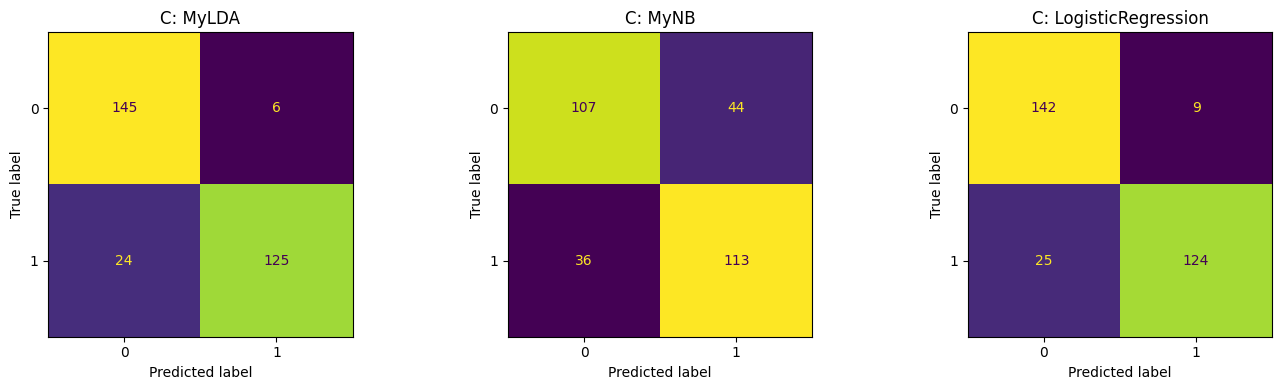

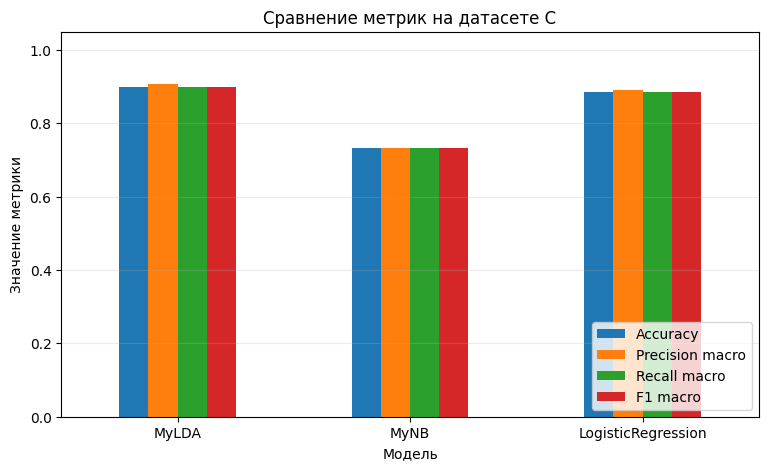


Сводная таблица:


,Dataset,Model,Accuracy,Precision class 0,Precision class 1,Recall class 0,Recall class 1,F1 class 0,F1 class 1,Precision macro,Recall macro,F1 macro
0,A,MyLDA,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,A,MyNB,0.8433,0.8323,0.8552,0.8600,0.8267,0.8459,0.8407,0.8437,0.8433,0.8433
2,A,LogisticRegression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,B,MyLDA,0.4500,0.4444,0.4545,0.4000,0.5000,0.4211,0.4762,0.4495,0.4500,0.4486
4,B,MyNB,0.9833,0.9739,0.9932,0.9933,0.9733,0.9835,0.9832,0.9835,0.9833,0.9833
5,B,LogisticRegression,0.4433,0.4380,0.4479,0.4000,0.4867,0.4181,0.4665,0.4429,0.4433,0.4423
6,C,MyLDA,0.9000,0.8580,0.9542,0.9603,0.8389,0.9062,0.8929,0.9061,0.8996,0.8996
7,C,MyNB,0.7333,0.7483,0.7197,0.7086,0.7584,0.7279,0.7386,0.7340,0.7335,0.7332
8,C,LogisticRegression,0.8867,0.8503,0.9323,0.9404,0.8322,0.8931,0.8794,0.8913,0.8863,0.8863


In [ ]:
def evaluate_dataset(X, y, dataset_name):
    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    models = {
        'MyLDA': MyLDA(),
        'MyNB': MyNB(),
        'LogisticRegression': LogisticRegression(max_iter=2000)
    }

    rows = []
    predictions = {}

    for model_name, model in models.items():
        model.fit(X_train_d, y_train_d)
        pred = model.predict(X_test_d)
        predictions[model_name] = pred

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test_d, pred, labels=[0, 1], zero_division=0
        )
        p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
            y_test_d, pred, average='macro', zero_division=0
        )

        rows.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Accuracy': accuracy_score(y_test_d, pred),
            'Precision class 0': precision[0],
            'Precision class 1': precision[1],
            'Recall class 0': recall[0],
            'Recall class 1': recall[1],
            'F1 class 0': f1[0],
            'F1 class 1': f1[1],
            'Precision macro': p_macro,
            'Recall macro': r_macro,
            'F1 macro': f1_macro
        })

    results_df = pd.DataFrame(rows)
    display(results_df.round(4))

    # Confusion matrix для каждой модели
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (model_name, pred) in zip(axes, predictions.items()):
        cm = confusion_matrix(y_test_d, pred)
        ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(ax=ax, colorbar=False)
        ax.set_title(f'{dataset_name}: {model_name}')
    plt.tight_layout()
    plt.show()

    # Столбчатая диаграмма основных метрик
    plot_df = results_df.set_index('Model')[['Accuracy', 'Precision macro', 'Recall macro', 'F1 macro']]
    plot_df.plot(kind='bar', figsize=(9, 5))
    plt.ylim(0, 1.05)
    plt.ylabel('Значение метрики')
    plt.xlabel('Модель')
    plt.title(f'Сравнение метрик на датасете {dataset_name}')
    plt.legend(loc='lower right')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.25)
    plt.show()

    return results_df

all_results = []
for name, (Xd, yd) in datasets.items():
    print()
    print(f'===== Датасет {name} =====')
    all_results.append(evaluate_dataset(Xd, yd, name))

results = pd.concat(all_results, ignore_index=True)
print()
print('Сводная таблица:')
display(results.round(4))

### 6.3 Анализ результатов
В Markdown-ячейке напишите **развернутый вывод**:
- На каком датасете LDA превосходит NB? Почему?
- На каком датасете NB работает лучше? Почему?
- Как влияет размерность пространства на обе модели?
- Когда обе модели падают (датасет C) — почему?

**Визуализация:** для каждого датасета постройте столбчатую диаграмму сравнения метрик.

На датасете A лучше работает LDA, потому что у классов одинаковая ковариационная матрица, и это хорошо совпадает с его предположениями. Naive Bayes здесь работает хуже, так как не учитывает зависимость между признаками. На датасете B лучше показывает себя Naive Bayes, потому что признаки внутри классов независимы, а их дисперсии могут отличаться. LDA в этом случае менее удобен, так как использует одну общую ковариационную матрицу. На датасете C обе модели работают хуже, потому что там одновременно есть разные ковариации, корреляции между признаками и шум в метках. Также при большом числе признаков Naive Bayes обычно устойчивее, потому что ему нужно оценивать меньше параметров.

**Итоговый вывод:** LDA и Naive Bayes используют вероятностный подход к классификации, но делают разные предположения о данных. LDA лучше подходит, когда у классов похожая ковариационная структура, а Naive Bayes — когда признаки можно считать независимыми. Если эти условия нарушаются, качество моделей снижается. Поэтому при выборе метода важно учитывать не только точность на тесте, но и то, как устроены сами данные.